# Feature engineering: New version

## Load data and imports

In [1]:
import yaml, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200, 'display.max_columns', 40)

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW  = ROOT / cfg['paths']['raw']
PROC = ROOT / cfg['paths']['processed']; PROC.mkdir(parents=True, exist_ok=True)
fcfg, v2cfg = cfg['features'], cfg['features_v2']
h, min_group = cfg['labels']['horizon'], cfg['labels']['min_group']

metadata = pd.read_parquet(RAW / 'metadata.parquet')
prices = pd.read_parquet(RAW / 'prices.parquet')
prices.index.name = 'date'; prices.columns.name = 'ticker'

# delisted-inclusive panel: drop leveraged + bad ticks, keep only categories big enough for a label
badf = metadata['is_leveraged'].fillna(False) | metadata['bad_ticks'].fillna(False)
prices = prices.drop(columns=[t for t in metadata.index[badf] if t in prices.columns])
cat = metadata['category'].reindex(prices.columns)
sizes = cat.value_counts()
keep_cats = sizes[(sizes >= min_group) & (sizes.index != 'Uncategorized')].index
keep = cat[cat.isin(keep_cats)].index
prices, cat = prices[keep], cat[keep]

market_data = pd.read_parquet(RAW / 'market_data.parquet')
high   = market_data["High"].reindex(index=prices.index, columns=prices.columns)
low    = market_data["Low"].reindex(index=prices.index, columns=prices.columns)
volume = market_data["Volume"].reindex(index=prices.index, columns=prices.columns)

ret_1d = prices.pct_change(1, fill_method=None)
active = prices.notna()
print('panel:', prices.shape, '|', len(keep_cats), 'categories')

panel: (2514, 1579) | 35 categories


## Return 

In [2]:
ret_1d  = prices.pct_change(1,  fill_method=None)
ret_5d  = prices.pct_change(5,  fill_method=None)
ret_10d = prices.pct_change(10, fill_method=None)
ret_20d = prices.pct_change(20, fill_method=None)
ret_60d = prices.pct_change(60, fill_method=None)

## Trend

In [3]:
ema_20 = prices.ewm(span=20, adjust=False).mean()
ema_50 = prices.ewm(span=50, adjust=False).mean()
ema20_dist = prices / ema_20 - 1.0
ema50_dist = prices / ema_50 - 1.0

ema_12 = prices.ewm(span=12, adjust=False).mean()
ema_26 = prices.ewm(span=26, adjust=False).mean()
macd = ema_12 - ema_26
macd_signal = macd.ewm(span=9, adjust=False).mean()
macd_hist = macd - macd_signal

# ADX14 — Wilder smoothing == ewm(alpha=1/period, adjust=False), vectorized
period = 14
prev_close = prices.shift(1)
up_move   = high.diff()
down_move = -low.diff()
plus_dm  = up_move.where((up_move > down_move) & (up_move > 0), 0.0)
minus_dm = down_move.where((down_move > up_move) & (down_move > 0), 0.0)
tr = np.maximum(high - low, np.maximum((high - prev_close).abs(), (low - prev_close).abs()))
atr_14 = tr.ewm(alpha=1/period, adjust=False).mean()
plus_di  = 100 * plus_dm.ewm(alpha=1/period, adjust=False).mean()  / atr_14
minus_di = 100 * minus_dm.ewm(alpha=1/period, adjust=False).mean() / atr_14
dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
adx_14 = dx.ewm(alpha=1/period, adjust=False).mean()

## Mean reversion

In [4]:
delta = prices.diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
rsi_14 = 100 - (100 / (1 + rs))

period = 14
highest_high_14 = high.rolling(period).max()
lowest_low_14 = low.rolling(period).min()
hl_range_14 = (highest_high_14 - lowest_low_14).replace(0, np.nan)   # flat 14d window -> NaN, not inf

willr_14 = (-100 * (highest_high_14 - prices) / hl_range_14).clip(-100, 0)

bb_mid = prices.rolling(20).mean()
bb_std = prices.rolling(20).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std
bb_pctb = (prices - bb_lower) / (bb_upper - bb_lower)

stoch_k = (100 * (prices - lowest_low_14) / hl_range_14).clip(0, 100)
stoch_d = stoch_k.rolling(3).mean()

## Volatility and Volume

In [5]:
vol_20d = ret_1d.rolling(20).std()
vol_zscore = (
    (vol_20d - vol_20d.rolling(252, min_periods=60).mean())
    / vol_20d.rolling(252, min_periods=60).std()
)

bb_bandwidth = (bb_upper - bb_lower) / bb_mid
atr_pct = atr_14 / prices   # normalized ATR (== NATR/100)

cat_mean_ret_1d = ret_1d.T.groupby(cat).transform("mean").T
window = 60
roll_x  = ret_1d.rolling(window).mean()
roll_m  = cat_mean_ret_1d.rolling(window).mean()
roll_xm = (ret_1d * cat_mean_ret_1d).rolling(window).mean()
cov_xm  = roll_xm - roll_x * roll_m
roll_m2 = (cat_mean_ret_1d ** 2).rolling(window).mean()
var_m   = roll_m2 - roll_m ** 2
beta_60d = cov_xm / var_m
# Volume
typical_price = (high + low + prices) / 3
raw_money_flow = typical_price * volume
tp_change = typical_price.diff()
positive_flow = raw_money_flow.where(tp_change > 0, 0.0)
negative_flow = raw_money_flow.where(tp_change < 0, 0.0)

mfi_period = 14
positive_mf_sum = positive_flow.rolling(mfi_period).sum()
negative_mf_sum = negative_flow.rolling(mfi_period).sum()
money_ratio = positive_mf_sum / negative_mf_sum.replace(0, np.nan)
mfi_14 = 100 - (100 / (1 + money_ratio))

hl = high - low
mfm = ((prices - low) - (high - prices)) / hl.where(hl > 0)
mfm = mfm.clip(-1, 1).mask((hl == 0) & prices.notna(), 0.0)   # flat bar = zero flow, don't poison the 20d window
mfv = mfm * volume
cmf_20 = mfv.rolling(20).sum() / volume.rolling(20).sum()

rel_volume_20d = volume / volume.rolling(20).mean() - 1.0

## Cross Sectional, change in features and Regime

In [6]:
def cs_rank(df):
    return df.rank(axis=1, pct=True)

def cat_rank(df):
    return df.T.groupby(cat).rank(pct=True).T

cs_rank_ret_5d      = cs_rank(ret_5d)
cs_rank_ret_20d     = cs_rank(ret_20d)
cs_rank_rsi         = cs_rank(rsi_14)
cs_rank_volatility  = cs_rank(vol_20d)
cs_rank_volume      = cs_rank(volume)
peer_rank_20d       = cat_rank(ret_20d)      # defined before the delta below

# change / delta features
d_rsi_5d        = rsi_14 - rsi_14.shift(5)
d_peer_rank_5d  = peer_rank_20d - peer_rank_20d.shift(5)
d_vol_5d        = vol_20d - vol_20d.shift(5)
d_macd_hist_5d  = macd_hist - macd_hist.shift(5)
d_volume_pct_5d = cs_rank_volume - cs_rank_volume.shift(5)

# regime
mkt_ret_1d = ret_1d.mean(axis=1)
mkt_vol_20d = mkt_ret_1d.rolling(20).std()
mkt_vol_zscore = (
    (mkt_vol_20d - mkt_vol_20d.rolling(252, min_periods=60).mean())
    / mkt_vol_20d.rolling(252, min_periods=60).std()
)
breadth_50d = (prices > ema_50).sum(axis=1) / active.sum(axis=1)
cat_ret_5d  = ret_5d.T.groupby(cat).transform("mean").T
cat_disp_5d = ret_5d.T.groupby(cat).transform("std").T
cat_ret_20d = ret_20d.T.groupby(cat).transform("mean").T
beat_rate_20d = (ret_20d > cat_ret_20d).T.groupby(cat).transform("mean").T

## Make it all in float32 and Saving it

In [7]:
def stack(df):
    s = df.stack(future_stack=True)
    s.index.names = ["date", "ticker"]
    return s.astype(np.float32)

feature_frames = {
    # Returns
    "ret_1d": ret_1d, "ret_5d": ret_5d, "ret_10d": ret_10d,
    "ret_20d": ret_20d, "ret_60d": ret_60d,
    # Trend
    "ema20_dist": ema20_dist, "ema50_dist": ema50_dist,
    "macd": macd, "macd_signal": macd_signal, "macd_hist": macd_hist, "adx_14": adx_14,
    # Mean reversion
    "rsi_14": rsi_14, "willr_14": willr_14, "bb_pctb": bb_pctb,
    "stoch_k": stoch_k, "stoch_d": stoch_d,
    # Volatility
    "vol_20d": vol_20d, "vol_zscore": vol_zscore,
    "bb_bandwidth": bb_bandwidth, "atr_pct": atr_pct, "beta_60d": beta_60d,
    # Volume  (obv + raw dollar_vol_20d dropped — size-dominated / redundant)
    "mfi_14": mfi_14, "cmf_20": cmf_20, "rel_volume_20d": rel_volume_20d,
    # Cross-sectional
    "cs_rank_ret_5d": cs_rank_ret_5d, "cs_rank_ret_20d": cs_rank_ret_20d,
    "cs_rank_rsi": cs_rank_rsi, "cs_rank_volatility": cs_rank_volatility,
    "cs_rank_volume": cs_rank_volume, "peer_rank_20d": peer_rank_20d,
    # Delta / change
    "d_rsi_5d": d_rsi_5d, "d_peer_rank_5d": d_peer_rank_5d,
    "d_vol_5d": d_vol_5d, "d_macd_hist_5d": d_macd_hist_5d, "d_volume_pct_5d": d_volume_pct_5d,
    # Regime (category-broadcast)
    "cat_ret_5d": cat_ret_5d, "cat_disp_5d": cat_disp_5d, "beat_rate_20d": beat_rate_20d,
}

features_long = pd.concat({name: stack(df) for name, df in feature_frames.items()}, axis=1)

# market-wide regime series (one value per date) — join by date only
regime_daily = pd.DataFrame({
    "mkt_ret_1d": mkt_ret_1d.astype(np.float32),
    "mkt_vol_20d": mkt_vol_20d.astype(np.float32),
    "mkt_vol_zscore": mkt_vol_zscore.astype(np.float32),
    "breadth_50d": breadth_50d.astype(np.float32),
})
regime_daily.index.name = "date"
features_long = features_long.join(regime_daily, on="date")

print(features_long.shape)   # -> ~ (3.97M, 42)
features_long.head()

(3969606, 42)


ret_1d  ret_5d  ret_10d  ret_20d  ret_60d  ema20_dist  ema50_dist  macd  macd_signal  macd_hist  adx_14  rsi_14  willr_14  bb_pctb  stoch_k  stoch_d  vol_20d  vol_zscore  \
date       ticker                                                                                                                                                                              
2016-07-11 AAA        NaN     NaN      NaN      NaN      NaN         NaN         NaN   NaN          NaN        NaN     NaN     NaN       NaN      NaN      NaN      NaN      NaN         NaN   
           AADR       NaN     NaN      NaN      NaN      NaN         0.0         0.0   0.0          0.0        0.0     NaN     NaN       NaN      NaN      NaN      NaN      NaN         NaN   
           AAXJ       NaN     NaN      NaN      NaN      NaN         0.0         0.0   0.0          0.0        0.0     NaN     NaN       NaN      NaN      NaN      NaN      NaN         NaN   
           ABEQ       NaN     NaN      NaN      NaN      NaN         NaN         NaN   NaN          NaN        NaN     NaN     NaN       NaN      NaN      NaN      NaN      NaN         NaN   
           ACES       NaN     NaN      NaN      NaN      NaN         NaN         NaN   NaN          NaN        NaN     NaN     NaN       NaN      NaN      NaN      NaN      NaN         NaN   

                   bb_bandwidth  atr_pct  ...  cmf_20  rel_volume_20d  cs_rank_ret_5d  cs_rank_ret_20d  cs_rank_rsi  cs_rank_volatility  cs_rank_volume  peer_rank_20d  d_rsi_5d  d_peer_rank_5d  \
date       ticker                         ...                                                                                                                                                      
2016-07-11 AAA              NaN      NaN  ...     NaN             NaN             NaN              NaN          NaN                 NaN             NaN            NaN       NaN             NaN   
           AADR             NaN      NaN  ...     NaN             NaN             NaN              NaN          NaN                 NaN        0.176056            NaN       NaN             NaN   
           AAXJ             NaN      NaN  ...     NaN             NaN             NaN              NaN          NaN                 NaN        0.906439            NaN       NaN             NaN   
           ABEQ             NaN      NaN  ...     NaN             NaN             NaN              NaN          NaN                 NaN             NaN            NaN       NaN             NaN   
           ACES             NaN      NaN  ...     NaN             NaN             NaN              NaN          NaN                 NaN             NaN            NaN       NaN             NaN   

                   d_vol_5d  d_macd_hist_5d  d_volume_pct_5d  cat_ret_5d  cat_disp_5d  beat_rate_20d  mkt_ret_1d  mkt_vol_20d  mkt_vol_zscore  breadth_50d  
date       ticker                                                                                                                                           
2016-07-11 AAA          NaN             NaN              NaN         NaN          NaN            0.0         NaN          NaN             NaN          0.0  
           AADR         NaN             NaN              NaN         NaN          NaN            0.0         NaN          NaN             NaN          0.0  
           AAXJ         NaN             NaN              NaN         NaN          NaN            0.0         NaN          NaN             NaN          0.0  
           ABEQ         NaN             NaN              NaN         NaN          NaN            0.0         NaN          NaN             NaN          0.0  
           ACES         NaN             NaN              NaN         NaN          NaN            0.0         NaN          NaN             NaN          0.0  

[5 rows x 42 columns]

In [38]:
OUT_PATH = PROC / "features_v3.parquet"
features_long.to_parquet(OUT_PATH)
print(f"saved: {OUT_PATH}  ({OUT_PATH.stat().st_size / 1e6:.1f} MB)")
print(features_long.shape)

saved: C:\Users\user\Desktop\CS\overp\outperforming\data\processed\features_v3.parquet  (561.0 MB)
(3969606, 44)


# EDA

=== summary ===


,count,mean,std,min,25%,50%,75%,max,missing_pct,skew
ret_1d,3367736.0,0.000382,0.012644,-0.423792,-0.004043,2.810372e-04,0.005281,0.427666,15.16,-3.723494e-01
ret_5d,3361403.0,0.001880,0.027477,-0.536913,-0.008148,1.669744e-03,0.013402,0.886819,15.32,-4.368879e-01
ret_10d,3353501.0,0.003746,0.038291,-0.735669,-0.010601,3.362604e-03,0.020601,1.181162,15.52,-6.634679e-01
ret_20d,3337718.0,0.007509,0.054157,-0.788804,-0.013944,6.666708e-03,0.031758,1.195869,15.92,-4.803218e-01
ret_60d,3274575.0,0.022164,0.091600,-0.807828,-0.016014,1.815149e-02,0.063170,2.080688,17.51,4.061916e-01
ema20_dist,3369413.0,0.002812,0.025790,-0.636943,-0.005987,3.412211e-03,0.014815,0.646073,15.12,-1.685699e+00
ema50_dist,3369413.0,0.007235,0.040454,-0.735686,-0.007396,8.034892e-03,0.026998,0.991508,15.12,-1.247072e+00
macd,3575634.0,0.111916,0.972534,-52.484184,-0.090619,6.358990e-02,0.296605,47.972305,9.92,8.638017e-01
macd_signal,3575634.0,0.111396,0.920836,-45.694557,-0.081995,6.218483e-02,0.283668,44.653637,9.92,1.243460e+00
macd_hist,3575634.0,0.000520,0.276470,-17.311970,-0.046806,2.775558e-17,0.051804,18.398529,9.92,-5.829985e-01


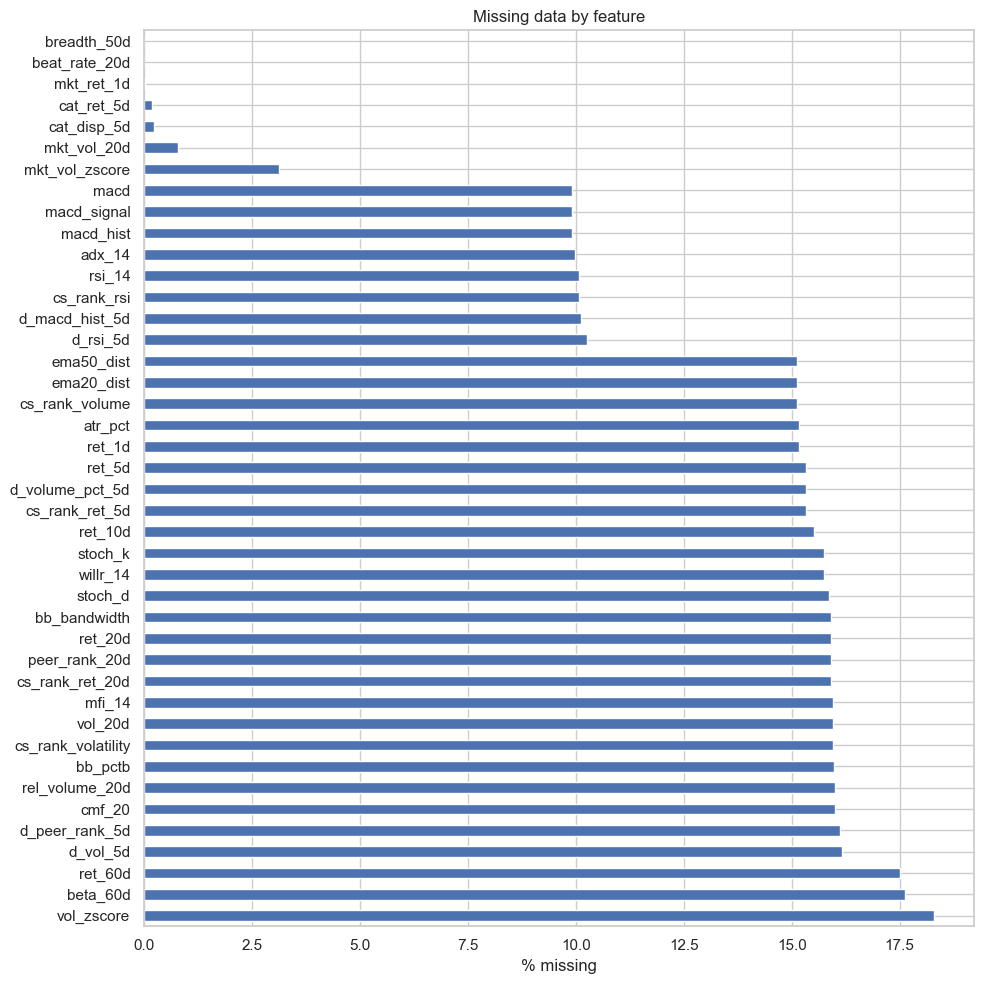

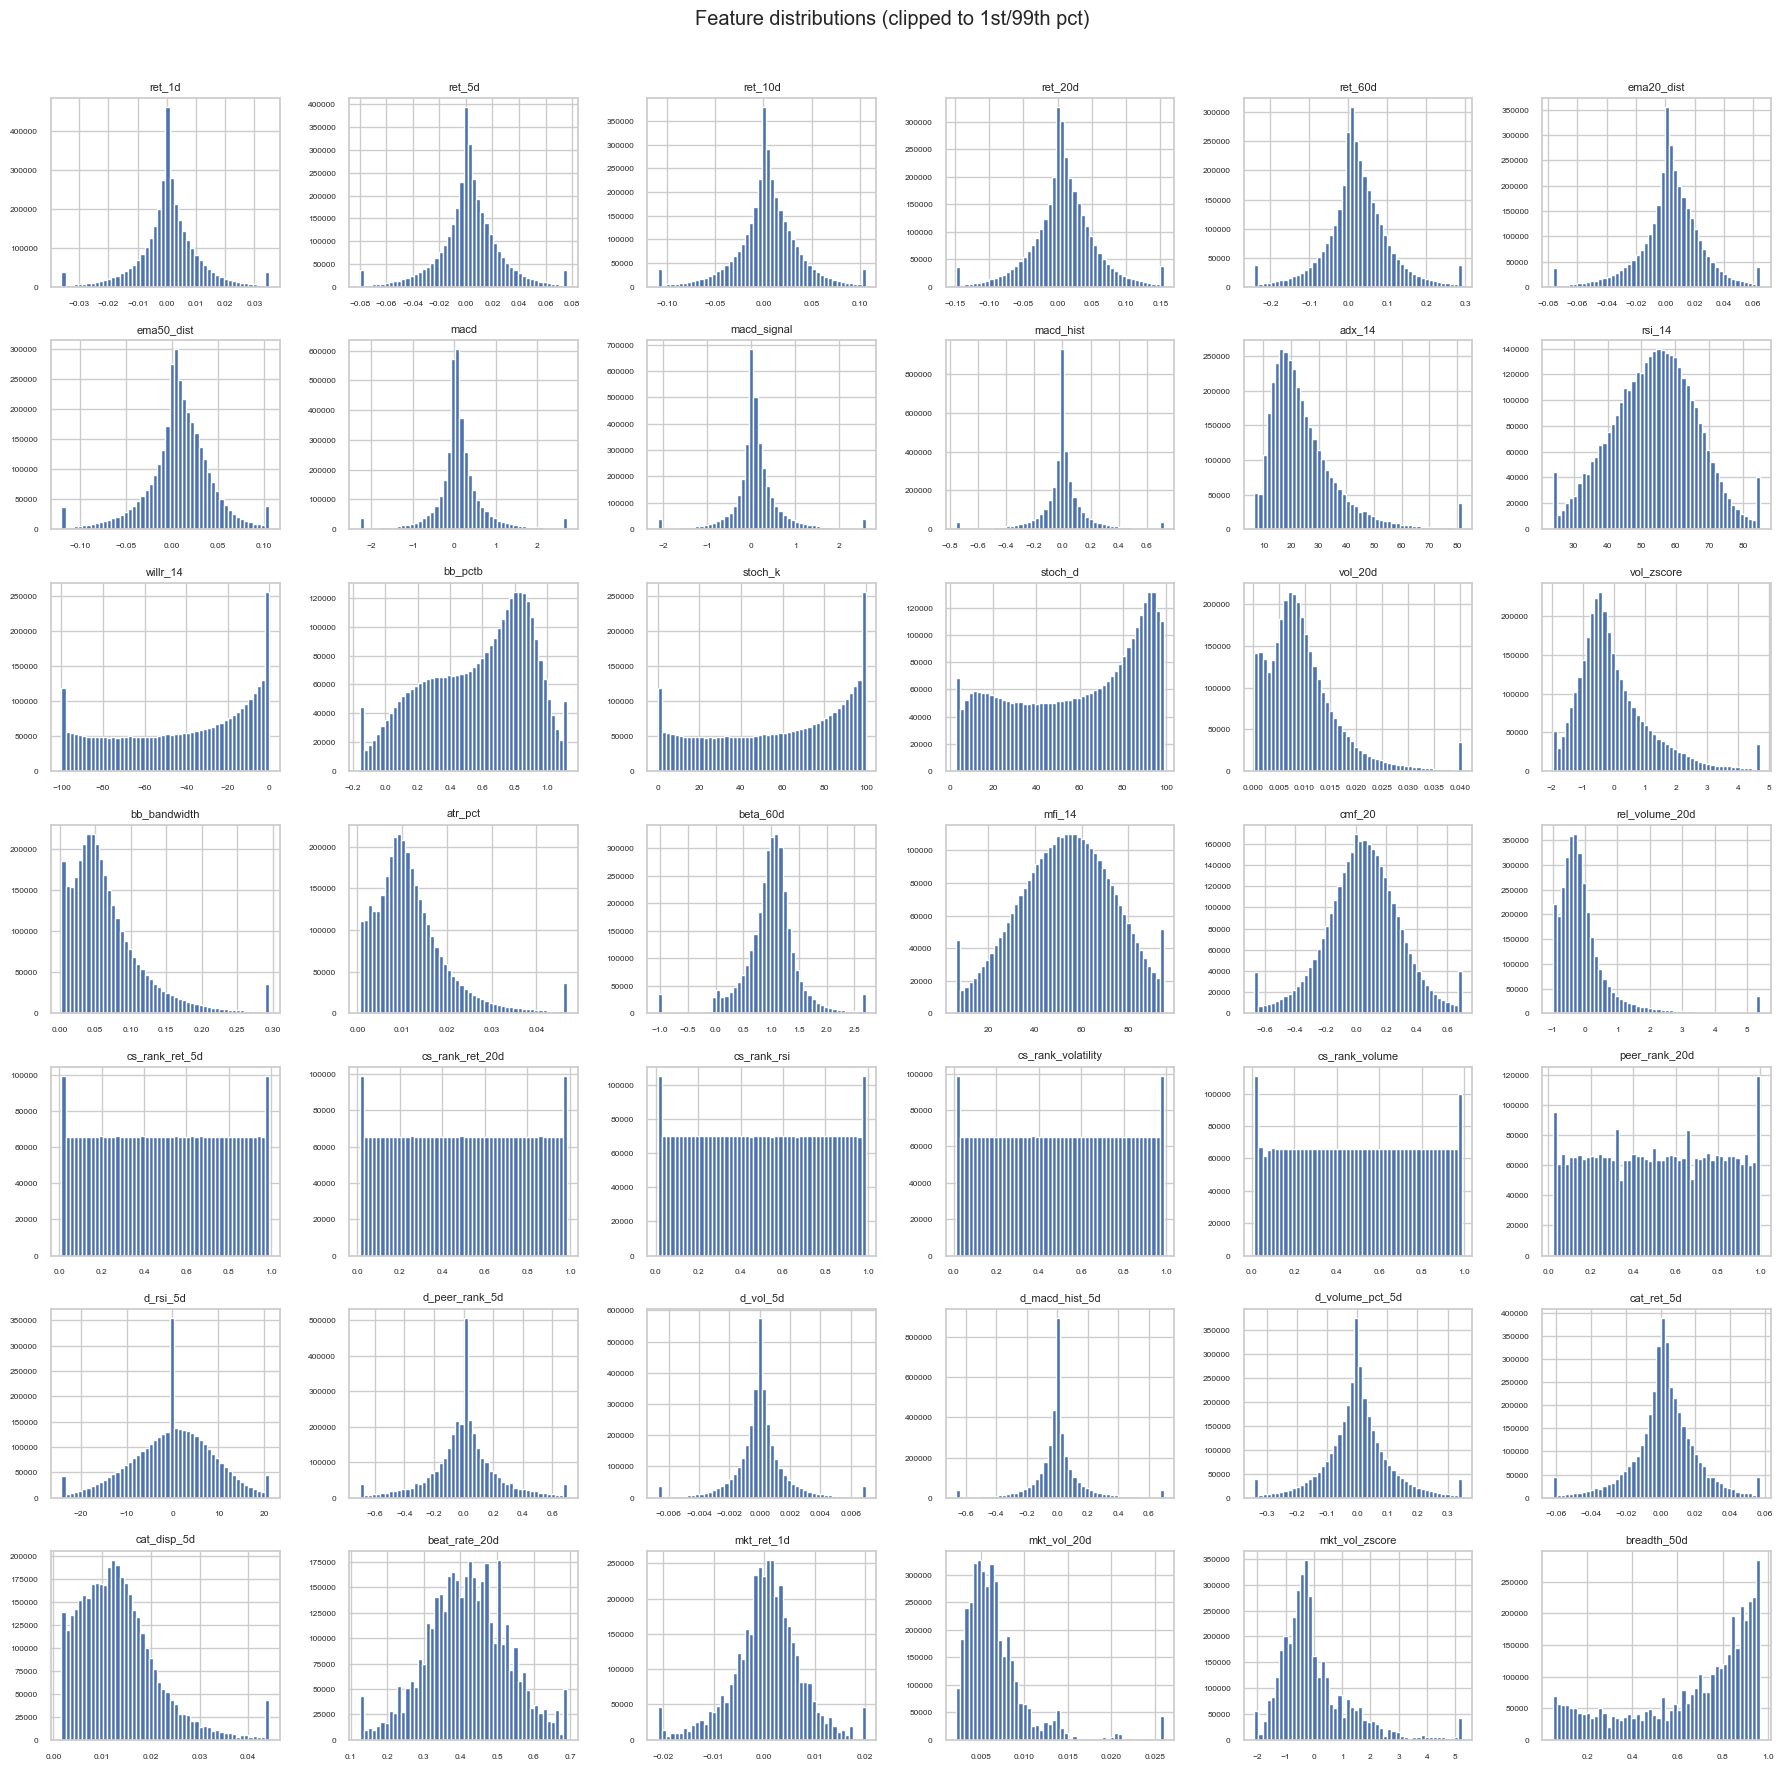

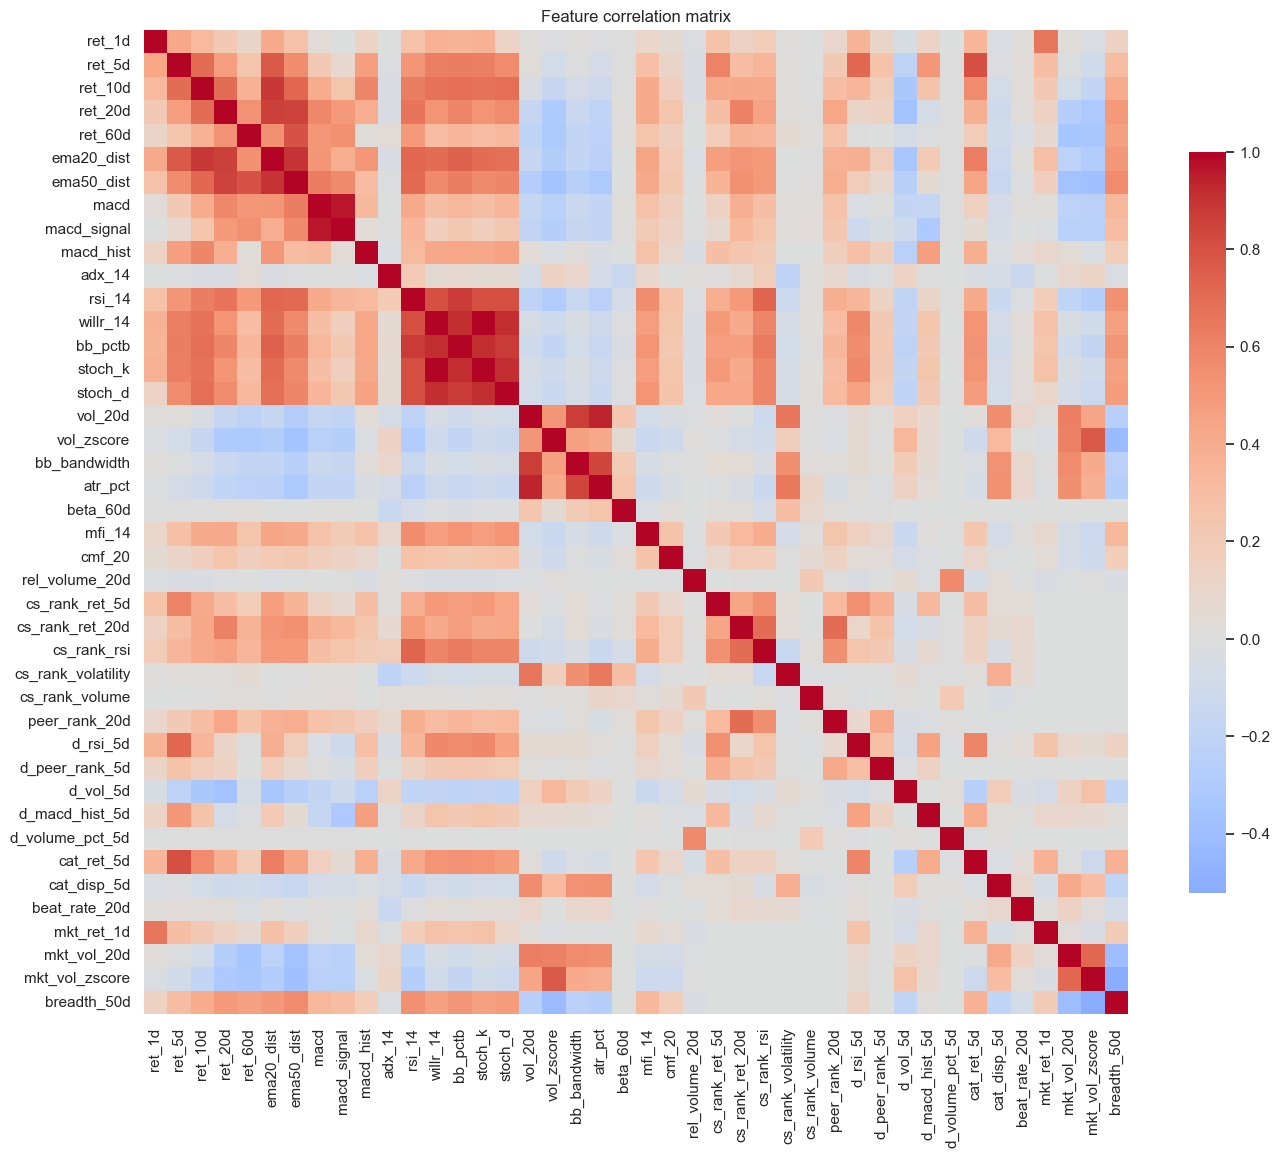

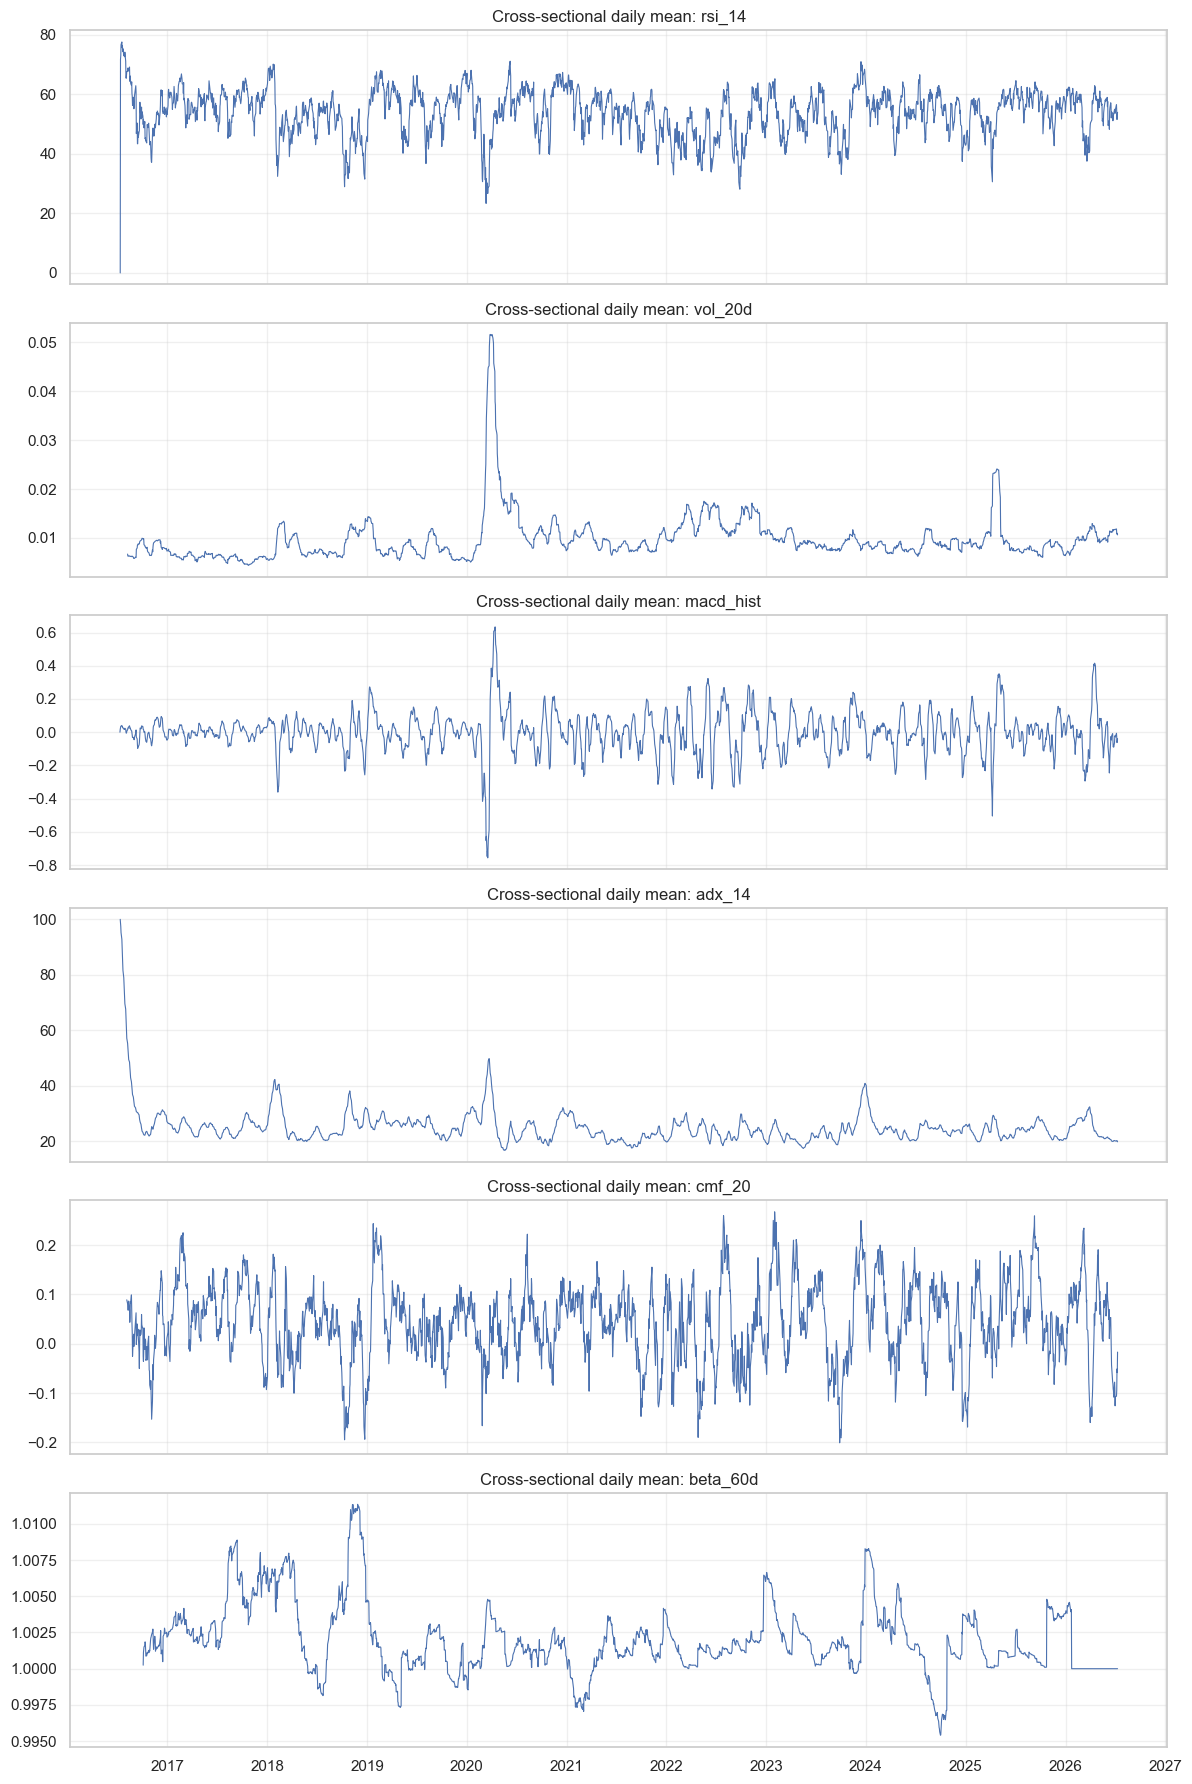

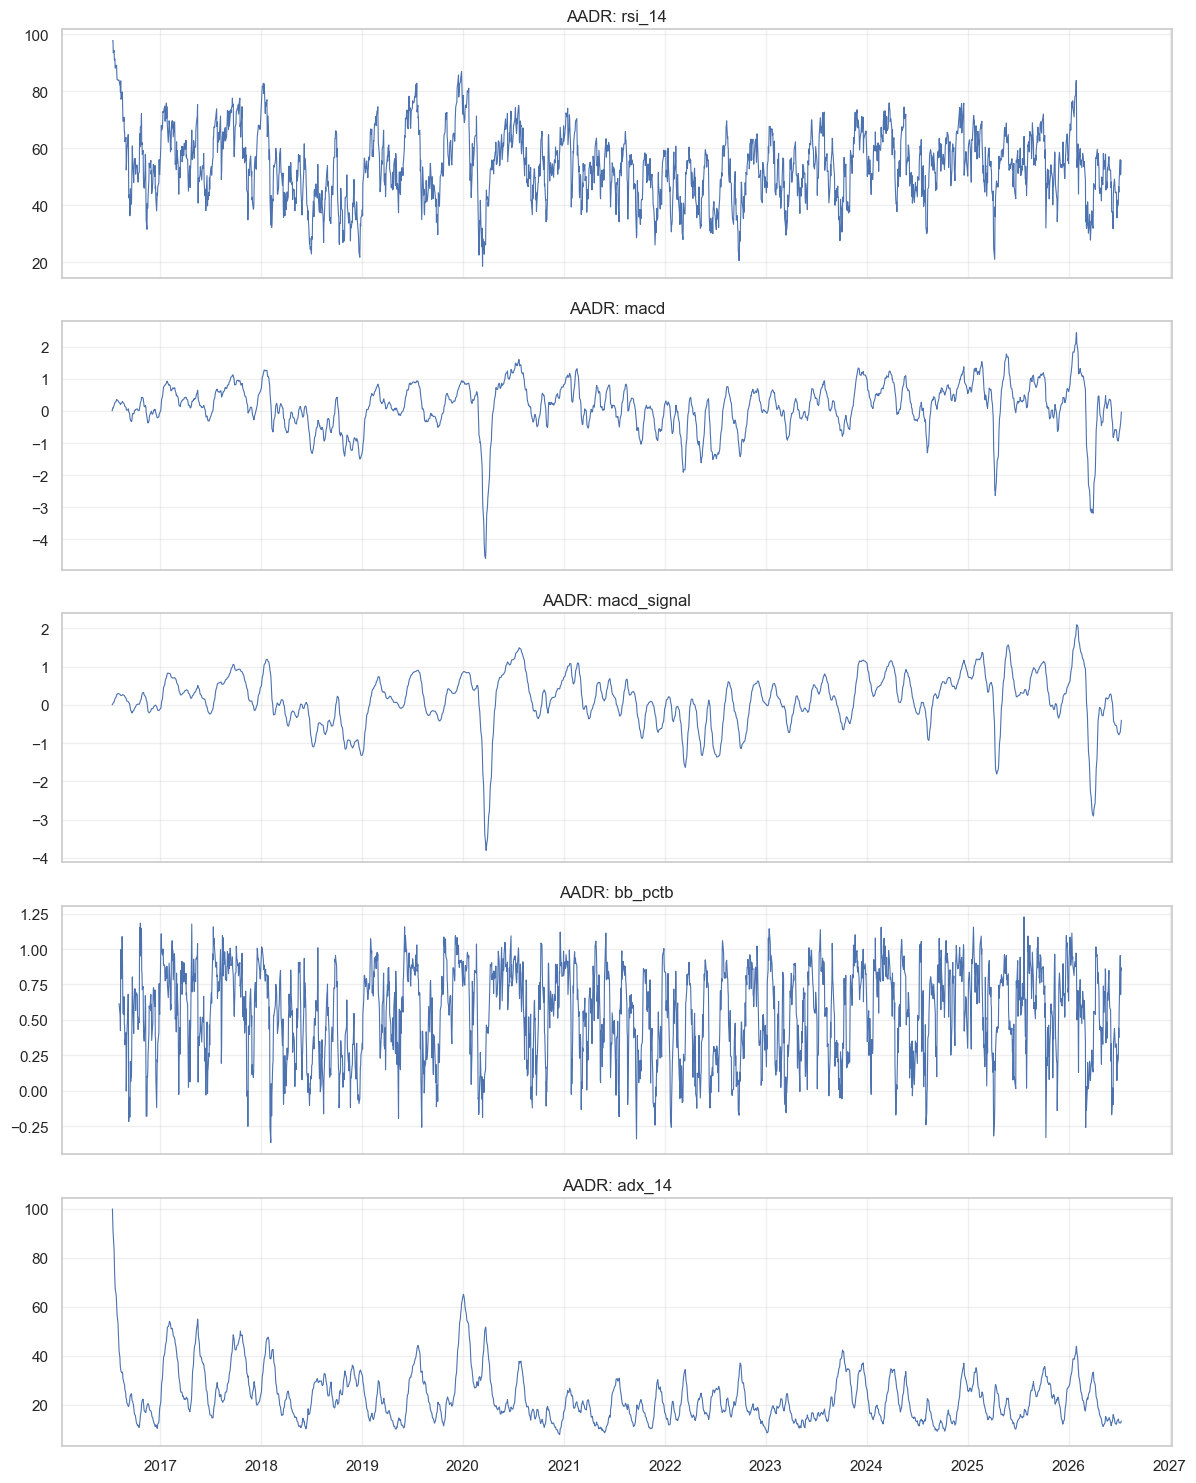

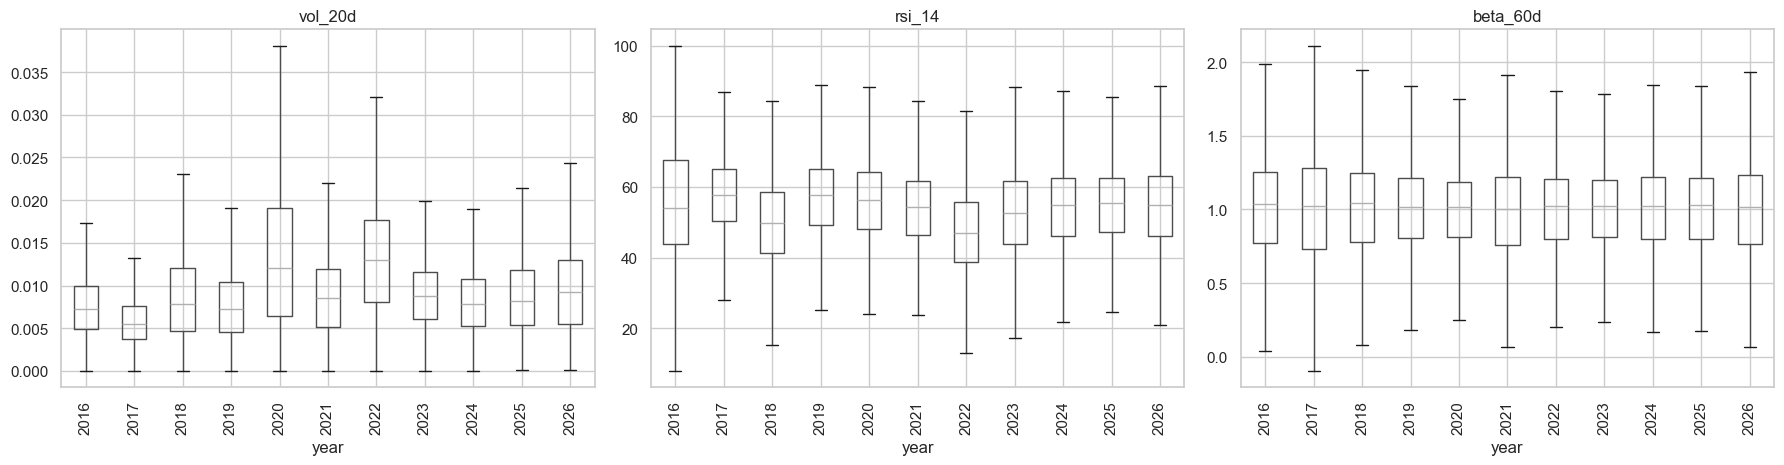

saved figures to C:\Users\user\Desktop\CS\overp\outperforming\notebooks\eda_v3


In [8]:
import pathlib

EDA_DIR = pathlib.Path("eda_v3")   # relative to the notebook (notebooks/eda_v3/)
EDA_DIR.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(EDA_DIR / f"{name}.png", dpi=110, bbox_inches="tight")

# ============================================================
# EDA — features_long
# ============================================================

# --- summary stats ---
summary = features_long.describe().T
summary["missing_pct"] = (features_long.isna().mean() * 100).round(2)
summary["skew"] = features_long.skew()
summary.to_csv(EDA_DIR / "summary.csv")   # so I can read the full table too
pd.set_option("display.max_rows", None)
print("=== summary ===")
display(summary)

# --- missingness by feature ---
missing_pct = features_long.isna().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 10))
missing_pct.plot(kind="barh", ax=ax, color="C0")
ax.set_xlabel("% missing")
ax.set_title("Missing data by feature")
plt.tight_layout()
save(fig, "01_missingness")
plt.show()

# --- distribution grid (all features) ---
cols = features_long.columns
ncols = 6
nrows = int(np.ceil(len(cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.5))
axes = axes.flatten()
for i, col in enumerate(cols):
    ax = axes[i]
    data = features_long[col].replace([np.inf, -np.inf], np.nan).dropna()
    lo, hi = data.quantile([0.01, 0.99])
    ax.hist(data.clip(lo, hi), bins=50, color="C0")
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=6)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.suptitle("Feature distributions (clipped to 1st/99th pct)", y=1.01)
plt.tight_layout()
save(fig, "02_distributions")
plt.show()

# --- correlation heatmap ---
corr = features_long.corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
save(fig, "03_correlation")
plt.show()

# --- cross-sectional daily mean over time ---
sample_features = ["rsi_14", "vol_20d", "macd_hist", "adx_14", "cmf_20", "beta_60d"]
fig, axes = plt.subplots(len(sample_features), 1, figsize=(12, 3 * len(sample_features)), sharex=True)
for ax, feat in zip(axes, sample_features):
    daily_mean = features_long[feat].groupby(level="date").mean()
    ax.plot(daily_mean.index, daily_mean.values, linewidth=0.8)
    ax.set_title(f"Cross-sectional daily mean: {feat}")
    ax.grid(alpha=0.3)
plt.tight_layout()
save(fig, "04_daily_mean")
plt.show()

# --- single-ticker sanity check ---
sample_ticker = "AADR"
sample_df = features_long.xs(sample_ticker, level="ticker")[
    ["rsi_14", "macd", "macd_signal", "bb_pctb", "adx_14"]
]
fig, axes = plt.subplots(len(sample_df.columns), 1, figsize=(12, 3 * len(sample_df.columns)), sharex=True)
for ax, col in zip(axes, sample_df.columns):
    ax.plot(sample_df.index, sample_df[col], linewidth=0.8)
    ax.set_title(f"{sample_ticker}: {col}")
    ax.grid(alpha=0.3)
plt.tight_layout()
save(fig, "05_single_ticker")
plt.show()

# --- distribution shift by year ---
box_df = features_long[["vol_20d", "rsi_14", "beta_60d"]].copy()
box_df["year"] = box_df.index.get_level_values("date").year
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["vol_20d", "rsi_14", "beta_60d"]):
    box_df.boxplot(column=col, by="year", ax=ax, rot=90, showfliers=False)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
save(fig, "06_yearly_shift")
plt.show()

print("saved figures to", EDA_DIR.resolve())

In [10]:
features_long[["ret_1d", "ret_20d", "rsi_14", "cmf_20"]].isna().sum(axis=1).value_counts().head(10)

0    3332574
4     395551
3     209729
2      25462
1       6290
Name: count, dtype: int64

In [28]:
features_long = features_long.dropna(
    subset=["ret_20d", "rsi_14", "cmf_20"]
)

ret_1d      395551
ret_20d     425552
rsi_14      399736
cmf_20     1222360
dtype: int64

# 03 · feature engineering — unified catalogue

one feature-building function, used by every notebook that needs features from here on. this
replaces four independently-drifted copies (nb03's old 17 technical, nb06's 36-feature
peer-relative v2, `Untitled.ipynb`'s 6-feature blueprint + volume, and the standalone
`feature_eng.py` script) with a single implementation, reconciled rather than pasted in unchanged
— two of `feature_eng.py`'s five features (`vol_20d`, `beta_60d`) turned out to use a materially
different construction than what's already here (see the catalogue below), not just a new name for
the same thing.

run 01 and 02 first. saves one `features.parquet` covering everything, replacing the five
overlapping `dataset_*.parquet` files that used to exist — notebook 04 selects whatever column
subset an experiment needs instead of each notebook hand-building its own dataset.

In [1]:
import yaml, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200, 'display.max_columns', 40)

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
import common
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW  = ROOT / cfg['paths']['raw']
PROC = ROOT / cfg['paths']['processed']; PROC.mkdir(parents=True, exist_ok=True)
fcfg, v2cfg = cfg['features'], cfg['features_v2']
h, min_group = cfg['labels']['horizon'], cfg['labels']['min_group']

metadata = pd.read_parquet(RAW / 'metadata.parquet')
prices = pd.read_parquet(RAW / 'prices.parquet')
prices.index.name = 'date'; prices.columns.name = 'ticker'

# delisted-INCLUSIVE panel (matches 05/06/Untitled, not the old survivorship-biased nb03/EDA view):
# drop leveraged + bad ticks, keep delisted funds, keep only categories big enough for a real label.
badf = metadata['is_leveraged'].fillna(False) | metadata['bad_ticks'].fillna(False)
prices = prices.drop(columns=[t for t in metadata.index[badf] if t in prices.columns])
cat = metadata['category'].reindex(prices.columns)
sizes = cat.value_counts(); keep_cats = sizes[(sizes >= min_group) & (sizes.index != 'Uncategorized')].index
keep = cat[cat.isin(keep_cats)].index
prices, cat = prices[keep], cat[keep]

market_data = pd.read_parquet(RAW / 'market_data.parquet')
volume = market_data.xs('Volume', axis=1, level=0)
volume.index.name = 'date'; volume.columns.name = 'ticker'
volume = volume.reindex(index=prices.index, columns=prices.columns)

print('panel:', prices.shape, '|', len(keep_cats), 'categories (delisted kept) | volume coverage:',
      volume.notna().any().sum(), '/', volume.shape[1], 'funds')

panel: (2514, 1579) | 35 categories (delisted kept) | volume coverage: 1579 / 1579 funds


## the feature catalogue — every feature and why it should work

### base set (30) — technical (17), friend-derived (3), position (4), alpha/propensity (7),
### context (5) — carried over from nb06, construction unchanged

- **trailing returns** `ret_1d, ret_5d, ret_10d, ret_20d` — raw momentum/reversal at horizons
  bracketing the label's week.
- **volatility** `vol_20d` — annualized 20d realized vol (log-return based).
- **trend distance** `px_to_sma_10/20/50`, `px_to_ema_10/20/50` — price vs its own moving averages.
- **oscillators** `rsi_14, macd, macd_signal, macd_hist, bb_pctb, bb_bandwidth`.
- **friend-derived** `ret_20d_skip5` (20d momentum skipping the reversal week), `beta_60d` (60d beta
  to the fund's own category composite), `rel_str_5d` (trailing 5d return minus category mean).
- **position within the pack** `cs_rank_ret_1d/5d`, `cs_rank_skip_mom`, `cs_rank_vol_20d` — pct-ranks
  within (date, category).
- **alpha vs beta** `resid_ret_5d/20d` (return minus `beta_60d ×` category return), `corr_cat_60d`
  (benchmark-hugger score), `idio_vol_20d`, `rel_vol_20d`, `tstat_rel_5d`, `beat_rate_20d`.
- **context** `px_to_52w_high`, `ret_60d_skip5`, `cat_disp_5d` (regime dial), `cat_ret_5d`, `cat_n`
  (peer-group size that day).

full rationale for each of these is in `06_features_v2.ipynb` (archived) — repeating it here would
just drift out of sync with this notebook again, which is exactly the problem being fixed.

### reconciling `feature_eng.py` (2 new, not just renamed)

`feature_eng.py` computes 5 features. `ret_5d` and `ret_20d_skip5` are identical to what's already
above. The other three needed a real decision, not a copy-paste:

- **`peer_rank_20d`** — pct-rank of raw `ret_20d` within (date, category). Computed in nb05 but
  explicitly kept **out** of modeling ("shares the ranking mechanism with the label" — a construction
  *similarity*, not proven leakage; nb06 already rebutted that argument in general for cross-sectional
  ranks, but never re-added this specific one, using `cs_rank_skip_mom` instead). Added here as a real,
  named, modelable feature — **`FENG`** group below — so notebook 04's ablation can settle whether it
  earns its place with actual numbers instead of leaving the question open.
- **`vol_20d`** — `feature_eng.py`'s version is simple-return std, **unannualized**. The existing
  `vol_20d` above is log-return std **annualized** by √252 — a different scale and, subtly, a
  different quantity. Kept both: `vol_20d` (unchanged) and **`vol_20d_raw`** (feature_eng.py's, new).
- **`beta_60d`** — `feature_eng.py` benchmarks each fund against its category **excluding itself**
  (leave-one-out mean). Every existing feature here that uses a category mean (`beta_60d`,
  `resid_ret_5d/20d`, `corr_cat_60d`, `idio_vol_20d`, `tstat_rel_5d`, `beat_rate_20d`, `cat_ret_5d`)
  **includes** the fund in its own benchmark — a mechanical self-correlation, worst in thin categories
  (as small as `min_group` here). Added `_xself` leave-one-out variants of all eight below (**`XSELF`**
  group) so notebook 04 can A/B include-self vs exclude-self directly. `cat_disp_5d` (a dispersion/std
  measure, not a mean) is excluded from this treatment — self-inclusion biases a *mean* far more
  mechanically than a *std*, so a leave-one-out version there wasn't judged worth the extra
  complexity.

### volume (3, new — from `Untitled.ipynb`, now backed by `market_data.parquet`)

- **`rel_volume_20d`** — 5d vs 20d own average volume: unusual trading interest vs the fund's own
  recent history.
- **`cs_rank_dollar_vol`** — pct-rank of volume×price (dollar flow) within (date, category):
  peer-relative attention.
- **`vol_zscore`** — cross-sectional z-score of raw share volume within (date, category).

`Untitled.ipynb`'s own ablation found a small, genuine lift from `cs_rank_dollar_vol` specifically —
the peer-relative framing, not raw own-history volume — which is exactly the pattern every other
feature group above already follows.

In [2]:
def rsi(px, p=14):
    d_ = px.diff(); up = d_.clip(lower=0); dn = -d_.clip(upper=0)
    ag = up.ewm(alpha=1/p, adjust=False, min_periods=p).mean(); al = dn.ewm(alpha=1/p, adjust=False, min_periods=p).mean()
    return 100 - 100 / (1 + ag / al)


def category_benchmark(rets, cat, mode='include_self'):
    """Trailing daily category-mean return. 'include_self' matches every notebook before this one
    (06/Untitled) -- the fund's own return is part of its own benchmark, a mechanical
    self-correlation that's worst in thin categories. 'exclude_self' is feature_eng.py's
    leave-one-out version (new to this project)."""
    if mode == 'include_self':
        return rets.T.groupby(cat).transform('mean').T
    cat_sum = rets.T.groupby(cat).transform('sum').T
    cat_count = rets.T.groupby(cat).transform('count').T
    return (cat_sum - rets) / (cat_count - 1).where(cat_count > 1)


def build_features(prices, cat, fcfg, v2cfg, benchmark='include_self'):
    """All price-derived features as wide (date x ticker) frames. Every input strictly trailing
    (data <= t). benchmark='include_self' (default, matches every notebook before this one) or
    'exclude_self' (feature_eng.py's leave-one-out category benchmark). Single function on purpose:
    the truncation check below re-runs it on a truncated panel."""
    rets = prices.pct_change(fill_method=None)
    catmean_ret = category_benchmark(rets, cat, benchmark)
    f = {}
    # --- base 17 technical ---
    f['ret_1d'] = rets
    for w in fcfg['return_windows']: f[f'ret_{w}d'] = prices.pct_change(w, fill_method=None)
    f['vol_20d'] = np.log(prices).diff().rolling(fcfg['vol_window']).std() * np.sqrt(252)
    for w in fcfg['sma_windows']: f[f'px_to_sma_{w}'] = prices / prices.rolling(w).mean() - 1
    for w in fcfg['ema_windows']: f[f'px_to_ema_{w}'] = prices / prices.ewm(span=w, adjust=False).mean() - 1
    f['rsi_14'] = rsi(prices, fcfg['rsi_period'])
    m = fcfg['macd']; ef, es = prices.ewm(span=m['fast'], adjust=False).mean(), prices.ewm(span=m['slow'], adjust=False).mean()
    line = ef - es; sig = line.ewm(span=m['signal'], adjust=False).mean()
    f['macd'] = line / prices; f['macd_signal'] = sig / prices; f['macd_hist'] = (line - sig) / prices
    b = fcfg['bollinger']; mid = prices.rolling(b['window']).mean(); sd = prices.rolling(b['window']).std()
    f['bb_pctb'] = (prices - (mid - b['num_std'] * sd)) / (2 * b['num_std'] * sd); f['bb_bandwidth'] = (2 * b['num_std'] * sd) / mid
    # --- friend-derived 3 ---
    W = v2cfg['corr_window']
    f['ret_20d_skip5'] = prices.shift(5) / prices.shift(25) - 1
    covm = (rets * catmean_ret).rolling(W).mean() - rets.rolling(W).mean() * catmean_ret.rolling(W).mean()
    f['beta_60d'] = covm / catmean_ret.rolling(W).var().clip(lower=1e-8)
    cat5 = category_benchmark(f['ret_5d'], cat, benchmark)
    f['rel_str_5d'] = f['ret_5d'] - cat5
    # --- position within the pack ---
    def cs_rank(w): return w.T.groupby(cat).rank(pct=True).T
    f['cs_rank_ret_1d'] = cs_rank(rets)
    f['cs_rank_ret_5d'] = cs_rank(f['ret_5d'])
    f['cs_rank_skip_mom'] = cs_rank(f['ret_20d_skip5'])
    f['cs_rank_vol_20d'] = cs_rank(f['vol_20d'])
    # --- alpha vs beta ---
    cat20 = category_benchmark(f['ret_20d'], cat, benchmark)
    f['resid_ret_5d'] = f['ret_5d'] - f['beta_60d'] * cat5
    f['resid_ret_20d'] = f['ret_20d'] - f['beta_60d'] * cat20
    # --- deviation propensity ---
    corr = rets.rolling(W).corr(catmean_ret)
    f['corr_cat_60d'] = corr
    f['idio_vol_20d'] = f['vol_20d'] * np.sqrt(1 - corr.clip(-1, 1) ** 2)
    f['rel_vol_20d'] = f['vol_20d'] / f['vol_20d'].T.groupby(cat).transform('mean').T
    f['tstat_rel_5d'] = f['rel_str_5d'] / (f['vol_20d'] / np.sqrt(252) * np.sqrt(5)).clip(lower=1e-6)
    wins = (rets > catmean_ret).astype(float).where(rets.notna() & catmean_ret.notna())
    f['beat_rate_20d'] = wins.rolling(v2cfg['beat_window'], min_periods=v2cfg['beat_window']).mean()
    # --- context ---
    f['px_to_52w_high'] = prices / prices.rolling(v2cfg['high_window'], min_periods=60).max() - 1
    sm = v2cfg['skip_mom']
    f['ret_60d_skip5'] = prices.shift(sm['skip']) / prices.shift(sm['skip'] + sm['window']) - 1
    f['cat_disp_5d'] = f['ret_5d'].T.groupby(cat).transform('std').T
    f['cat_ret_5d'] = cat5
    f['cat_n'] = f['ret_5d'].notna().T.groupby(cat).transform('sum').T.where(prices.notna())
    # --- feature_eng.py reconciliation (only computed once, on the include_self pass) ---
    if benchmark == 'include_self':
        f['peer_rank_20d'] = cs_rank(f['ret_20d'])
        f['vol_20d_raw'] = rets.rolling(fcfg['vol_window']).std()
    return f


def build_volume_features(prices, volume, cat):
    """rel_volume_20d, cs_rank_dollar_vol, vol_zscore -- from Untitled.ipynb, now backed by
    market_data.parquet. volume is reindexed to prices' own index/columns so a truncated `prices`
    (the truncation check below) only ever sees volume up to the same date."""
    volume = volume.reindex(index=prices.index, columns=prices.columns)
    dollar_vol = prices * volume
    f = {}
    f['rel_volume_20d'] = (volume.rolling(5).mean() / volume.rolling(20).mean().clip(lower=1e-6) - 1).clip(-5, 5)
    f['cs_rank_dollar_vol'] = dollar_vol.T.groupby(cat).rank(pct=True).T
    vmean = volume.T.groupby(cat).transform('mean').T
    vstd = volume.T.groupby(cat).transform('std').T
    f['vol_zscore'] = ((volume - vmean) / (vstd + 1e-8)).clip(-5, 5)
    return f

## build the feature panel

run `build_features` twice — once with the standard include-self benchmark (produces every
column except the `_xself` variants), once with exclude-self (only the leave-one-out variants get
kept) — plus the volume features, then assemble one wide feature matrix.

In [3]:
feat = build_features(prices, cat, fcfg, v2cfg, benchmark='include_self')
feat_xself = build_features(prices, cat, fcfg, v2cfg, benchmark='exclude_self')
feat.update(build_volume_features(prices, volume, cat))

for name in common.XSELF_BASE:
    feat[f'{name}_xself'] = feat_xself[name]
del feat_xself

# feature groups live in common.py -- single source of truth shared with notebook 04
TECH, FRIEND, POS, ALPHA, CTX = common.TECH, common.FRIEND, common.POS, common.ALPHA, common.CTX
FENG, XSELF, VOL = common.FENG, common.XSELF, common.VOL
D36, FEATURE_COLS = common.D36, common.FEATURE_COLS
assert set(feat.keys()) == set(FEATURE_COLS), f'feature build/list drifted apart: {set(feat) ^ set(FEATURE_COLS)}'

X = pd.concat({k: feat[k].stack() for k in FEATURE_COLS}, axis=1).astype('float32')
X.index.names = ['date', 'ticker']
print('feature matrix:', X.shape)
print(f'{len(D36)} base (nb06) + {len(FENG)} feature_eng.py-derived + {len(XSELF)} leave-one-out '
      f'variants + {len(VOL)} volume = {len(FEATURE_COLS)} total')

feature matrix: (3966681, 49)
36 base (nb06) + 2 feature_eng.py-derived + 8 leave-one-out variants + 3 volume = 49 total


## truncation check — leak-free by construction

rebuild every feature from `prices.loc[:t]` (and `volume` reindexed to match) at 3 random dates
since 2021, and compare against the full-panel value at that same date. proves each feature is
computable from data <= t alone. checks the price-derived features (both benchmark modes) and the
volume features separately, since they're built by two different functions.

In [4]:
bad_incself = common.truncation_check(
    lambda px: build_features(px, cat, fcfg, v2cfg, benchmark='include_self'),
    prices, D36 + FENG, n_dates=3, start='2021-01-01')
bad_xself = common.truncation_check(
    lambda px: build_features(px, cat, fcfg, v2cfg, benchmark='exclude_self'),
    prices, common.XSELF_BASE, n_dates=3, start='2021-01-01')
bad_vol = common.truncation_check(
    lambda px: build_volume_features(px, volume, cat),
    prices, VOL, n_dates=3, start='2021-01-01')

bad = bad_incself + bad_xself + bad_vol
n_checked = 3 * (len(D36) + len(FENG) + len(common.XSELF_BASE) + len(VOL))
print(f'truncation check: {n_checked - len(bad)}/{n_checked} (date, feature) cross-sections reproduce from data <= t')
assert not bad, f'lookahead detected in: {bad}'
print('PASS: every feature is computable from the truncated panel alone.')

truncation check: 147/147 (date, feature) cross-sections reproduce from data <= t
PASS: every feature is computable from the truncated panel alone.


## leakage audit — forward correlation

every feature's |corr| with the *forward* excess return (`rel` from `labels.parquet`). trailing
features should all be small; a spike would mean something is peeking ahead. (nb06's max was 0.037,
on `rel_str_5d`.)

In [5]:
labels = pd.read_parquet(PROC / 'labels.parquet')
excess = labels['rel']
leak = common.forward_correlation_audit(X, excess, FEATURE_COLS)
print('|corr(feature, forward excess)|, largest first:')
print(leak.round(3).to_string())
print()
print('MAX:', round(leak.max(), 3), '->', 'OK, trailing-sized' if leak.max() < 0.15 else 'INVESTIGATE')

|corr(feature, forward excess)|, largest first:
rel_str_5d             0.037
cs_rank_ret_1d         0.026
resid_ret_5d_xself     0.022
resid_ret_5d           0.021
cs_rank_ret_5d         0.020
ret_5d                 0.020
px_to_sma_10           0.018
ret_1d                 0.018
px_to_ema_10           0.017
corr_cat_60d           0.015
corr_cat_60d_xself     0.015
bb_bandwidth           0.014
beta_60d               0.013
beta_60d_xself         0.013
vol_20d                0.011
vol_20d_raw            0.010
px_to_ema_20           0.010
resid_ret_20d          0.010
cs_rank_vol_20d        0.010
resid_ret_20d_xself    0.009
idio_vol_20d_xself     0.009
ret_20d_skip5          0.009
idio_vol_20d           0.009
tstat_rel_5d           0.008
tstat_rel_5d_xself     0.008
cs_rank_skip_mom       0.007
px_to_sma_20           0.006
px_to_ema_50           0.006
rsi_14                 0.004
cat_disp_5d            0.004
rel_vol_20d            0.004
ret_10d                0.003
cat_ret_5d_xself       0

## save

delisted-inclusive, leak-checked, one file. notebook 04 joins this with `labels.parquet` itself
rather than a separately-persisted `dataset_*.parquet` -- one less copy to keep in sync.

In [6]:
X.to_parquet(PROC / 'features.parquet')
print('saved', X.shape, '->', PROC / 'features.parquet')

saved (3966681, 49) -> C:\Users\user\Desktop\CS\overp\outperforming\data\processed\features.parquet
